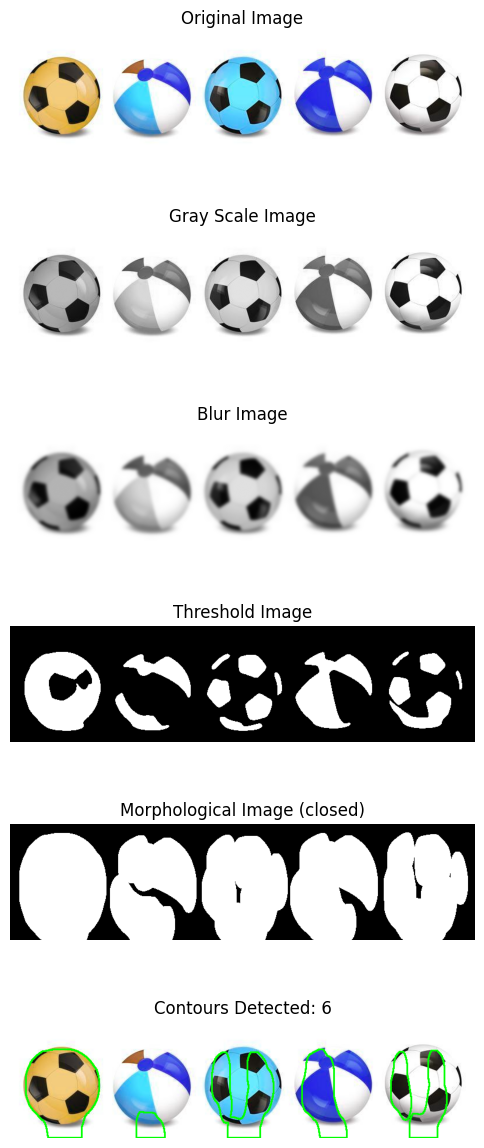

<Figure size 640x480 with 0 Axes>

In [155]:
plt.figure(figsize=(6, 15))  # Width x Height in inches

plt.subplot(6, 1, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(6, 1, 2)
plt.imshow(gray, cmap='gray')
plt.title("Gray Scale Image")
plt.axis('off')

plt.subplot(6, 1, 3)
plt.imshow(blur, cmap='gray')
plt.title("Blur Image")
plt.axis('off')

plt.subplot(6, 1, 4)
plt.imshow(otsu, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')

plt.subplot(6, 1, 5)
plt.imshow(closed, cmap='gray')
plt.title("Morphological Image (closed)")
plt.axis('off')


plt.subplot(6, 1, 6)
plt.imshow(cv2.drawContours(img_copy, filtered, -1, (0, 255, 0), 2))
plt.title(f"Contours Detected: {len(filtered)}")
plt.axis('off')
plt.show()

plt.tight_layout()
plt.show()

Saved: object_1.jpg
Saved: object_2.jpg
Saved: object_3.jpg
Saved: object_4.jpg
Saved: object_5.jpg
Saved: object_6.jpg


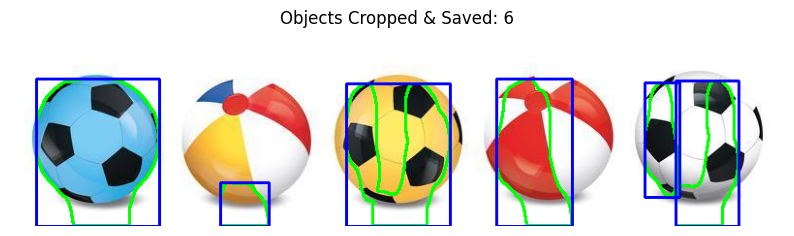

In [156]:
# Loop through each filtered contour to crop and save the object
for i, cnt in enumerate(filtered):
    # Get bounding box around the contour
    # Returns: x, y = top-left corner, w, h = width and height
    x, y, w, h = cv2.boundingRect(cnt)

    # Draw a rectangle on the original image for visual reference
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Blue box

    # Crop the object from the original image using NumPy slicing
    cropped_object = img[y:y+h, x:x+w]

    # Save the cropped object to file (you can change path if needed)
    filename = f"object_{i+1}.jpg"  # Output name: object_1.jpg, object_2.jpg, ...
    cv2.imwrite(filename, cropped_object)

    # (Optional) Print confirmation
    print(f"Saved: {filename}")

    
# Show final result with bounding boxes drawn
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title(f"Objects Cropped & Saved: {len(filtered)}")
plt.axis('off')
plt.show()